In [2]:
import numpy as np
from scipy.optimize import differential_evolution
import time
from numba import njit

data = np.array([
[0,13,12,13],
[10,14,11,14],
[20,13,12,13],
[30,13,11,14],
[40,14,11,14],
[50,14,12,13],
[60,13,11,13],
[70,13,11,13],
[80,13,11,13],
[90,14,11,13],
[100,14,11,13],
[110,14,11,13],
[120,14,12,13],
[130,13,11,13],
[140,14,11,13],
[150,14,11,13],
[160,13,11,13],
[170,12,12,13],
[180,13,10,14],
[190,13,12,13],
[200,13,11,12],
[210,13,11,12],
[220,14,12,13],
[230,13,11,13],
[240,14,12,13],
[250,13,11,13],
[260,13,11,12],
[270,13,11,13],
[280,12,11,13],
[290,13,11,14],
[300,12,12,14],
[310,13,11,13],
[320,13,12,13],
[330,13,12,13],
[340,13,12,13],
[350,12,12,12],
[360,13,12,13],
[370,14,12,13],
[380,13,12,13],
[390,14,12,13],
[400,13,12,13],
[410,13,12,14],
[420,13,12,13],
[430,13,12,13],
[440,13,12,13],
[450,13,12,14],
[460,13,13,13],
[470,13,13,14],
[480,13,12,13],
[490,13,13,13],
[500,14,13,13],
[510,13,13,13],
[520,13,12,13],
[530,12,12,13],
[540,14,12,13],
[550,13,12,14],
[560,13,13,13],
[570,13,13,13],
[580,13,12,13],
[590,15,12,13],
[600,14,13,13],
[610,13,13,13],
[620,14,13,13],
[630,13,13,13],
[640,14,13,14],
[650,14,13,13],
[660,14,13,13],
[670,14,13,14],
[680,14,14,14],
[690,14,14,13],
[700,14,13,13],
[710,14,13,13],
[720,14,14,13],
[730,13,13,13],
[740,14,14,13],
[750,14,14,14],
[760,14,13,13],
[770,15,14,13],
[780,14,14,13],
[790,14,14,14],
[800,14,13,14],
[810,14,14,13],
[820,13,14,13],
[830,15,14,14],
[840,14,14,14],
[850,14,14,14],
[860,15,13,14],
[870,14,14,13],
[880,15,14,14],
[890,15,14,14],
[900,15,14,13],
[910,14,15,13],
[920,14,15,14],
[930,15,14,14],
[940,15,15,14],
[950,14,15,14],
[960,14,15,14],
[970,15,15,14],
[980,15,15,14],
[990,15,15,15],
[1000,16,15,14],
[1010,15,15,15],
[1020,14,15,14],
[1030,14,15,15],
[1040,15,16,14],
[1050,15,15,14],
[1060,15,16,15],
[1070,14,15,15],
[1080,15,15,14],
[1090,15,16,15],
[1100,14,16,15],
[1110,14,16,14],
[1120,15,16,16],
[1130,15,16,15],
[1140,16,16,14],
[1150,15,16,15],
[1160,16,16,15],
[1170,15,16,15],
[1180,15,16,15],
[1190,15,16,15],
[1200,15,16,14],
[1210,15,17,15],
[1220,15,16,15],
[1230,16,16,15],
[1240,16,16,15],
[1250,16,16,15],
[1260,16,16,14],
[1270,16,16,14],
[1280,15,16,16],
[1290,15,16,15],
[1300,15,17,15],
[1310,15,17,15],
[1320,15,17,16],
[1330,15,16,15],
[1340,16,16,15],
[1350,16,17,16],
[1360,16,17,15],
[1370,15,18,15],
[1380,16,17,15],
[1390,16,17,15],
[1400,16,17,16],
[1410,16,17,15],
[1420,15,17,16],
[1430,16,17,16],
[1440,16,17,16],
[1450,16,17,16],
[1460,17,17,16],
[1470,17,17,16],
[1480,16,17,16],
[1490,17,18,16],
[1500,16,18,16],
[1510,16,18,16],
[1520,16,17,16],
[1530,17,18,16],
[1540,16,18,17],
[1550,16,18,16],
[1560,16,17,17],
[1570,17,17,16],
[1580,17,18,17],
[1590,17,18,16],
[1600,16,17,16],
[1610,16,18,16],
[1620,16,19,16],
[1630,17,17,16],
[1640,17,18,17],
[1650,17,18,17],
[1660,16,18,16],
[1670,16,19,16],
[1680,17,18,16],
[1690,16,19,16],
[1700,17,18,17],
[1710,16,18,16],
[1720,17,18,17],
[1730,17,18,17],
[1740,17,19,16],
[1750,17,19,17],
[1760,17,19,17],
[1770,18,19,17],
[1780,17,19,17],
[1790,17,19,17],
[1800,18,19,17],
[1810,18,19,16],
[1820,17,18,16],
[1830,17,19,16],
[1840,18,19,17],
[1850,18,20,16],
[1860,18,19,16],
[1870,17,19,16],
[1880,18,19,17],
[1890,18,19,17],
[1900,18,20,17],
[1910,17,19,17],
[1920,18,20,17],
[1930,19,19,17],
[1940,18,19,16],
[1950,18,20,18],
[1960,17,20,16],
[1970,18,20,18],
[1980,18,19,17],
[1990,18,20,17],
[2000,18,20,17],
[2010,17,20,17],
[2020,18,19,17],
[2030,18,19,18],
[2040,18,20,18],
[2050,18,19,17],
[2060,18,20,17],
[2070,19,19,18]
], dtype=np.float64)

t_exp = data[:, 0]
T_center_exp = data[:, 1]
T_hot_exp = data[:, 2]
T_top_exp = data[:, 3]

L = 0.045
N = 23
dx = L / (N - 1)
dt = 0.05
Fo_max = 1.0 / 6.0

rho = 1050.0
cp = 3500.0
T_air = 19.0

def initialize_T(alpha, h):
    T = np.full((N, N, N), 13.0)
    T[:, :, 0] = 0.0

    for _ in range(2000):
        T = step_numba(T, alpha, 0.0, dx, dt, h, Fo_max, heater_on=False)
    return T

def get_pos(x, y, z):
    return np.array([x / L * (N - 1), y / L * (N - 1), z / L * (N - 1)], dtype=np.float64)

@njit(fastmath=True)
def sample_temp(T, px, py, pz):
    x0, y0, z0 = int(px), int(py), int(pz)
    x1, y1, z1 = x0+1, y0+1, z0+1

    x0 = max(0, min(x0, N-2))
    y0 = max(0, min(y0, N-2))
    z0 = max(0, min(z0, N-2))
    x1 = x0+1; y1 = y0+1; z1 = z0+1

    xd, yd, zd = px-x0, py-y0, pz-z0

    c00 = T[x0,y0,z0]*(1-xd)+T[x1,y0,z0]*xd
    c01 = T[x0,y0,z1]*(1-xd)+T[x1,y0,z1]*xd
    c10 = T[x0,y1,z0]*(1-xd)+T[x1,y1,z0]*xd
    c11 = T[x0,y1,z1]*(1-xd)+T[x1,y1,z1]*xd

    return (c00*(1-yd)+c10*yd)*(1-zd)+(c01*(1-yd)+c11*yd)*zd

@njit(fastmath=True)
def step_numba(T, alpha, q, dx, dt, h, Fo_max, heater_on=True):
    Tn = T.copy()
    Fo = alpha*dt/(dx*dx)

    if Fo > Fo_max*1.1:
        T[:] = 1e6
        return T

    Nx,Ny,Nz = T.shape

    for i in range(1,Nx-1):
        for j in range(1,Ny-1):
            for k in range(1,Nz-1):
                lap = (Tn[i+1,j,k]+Tn[i-1,j,k]+
                       Tn[i,j+1,k]+Tn[i,j-1,k]+
                       Tn[i,j,k+1]+Tn[i,j,k-1]-6*Tn[i,j,k])/(dx*dx)
                T[i,j,k]=Tn[i,j,k]+dt*alpha*lap

    for i in range(Nx):
        for j in range(Ny):
            T[i,j,0]=0.0

    for j in range(Ny):
        for k in range(Nz):
            T[0,j,k]-=h*(T[0,j,k]-T_air)*dt
            T[-1,j,k]-=h*(T[-1,j,k]-T_air)*dt

    for i in range(Nx):
        for k in range(Nz):
            T[i,0,k]-=h*(T[i,0,k]-T_air)*dt
            T[i,-1,k]-=h*(T[i,-1,k]-T_air)*dt

    for i in range(Nx):
        for j in range(Ny):
            T[i,j,-1]-=h*(T[i,j,-1]-T_air)*dt

    if not heater_on:
        return T

    j_p = Nx-1
    i_p = Ny//2
    k_p = Nz//2

    sigma=2.0
    norm=0.0

    for i in range(Nx):
        for k in range(Nz):
            norm += np.exp(-((i-i_p)**2+(k-k_p)**2)/(2*sigma**2))

    for i in range(Nx):
        for k in range(Nz):
            w=np.exp(-((i-i_p)**2+(k-k_p)**2)/(2*sigma**2))/norm
            T[i,j_p,k]+=q*dt*w

    return T

def simulate(alpha,P,h):
    T = initialize_T(alpha, h)

    Tc=np.empty(len(t_exp))
    Th=np.empty(len(t_exp))
    Tt=np.empty(len(t_exp))

    t=0.0
    i=0
    max_T=0.0

    while i<len(t_exp):
        while t<t_exp[i]:
            T=step_numba(T,alpha,P,dx,dt,h,Fo_max,True)
            t+=dt

        Tc[i]=sample_temp(T,*get_pos(0.0225,0.0225,0.0225))
        Th[i]=sample_temp(T,*get_pos(0.0225,0.0275,0.0225))
        Tt[i]=sample_temp(T,*get_pos(0.035,0.018,0.027))

        max_T=max(max_T,Tc[i],Th[i],Tt[i])
        i+=1

    return Tc,Th,Tt,max_T

def loss(p):
    alpha,P,h=p

    if alpha<=0 or P<=0 or h<=0:
        return 1e9

    Tc,Th,Tt,max_T = simulate(alpha,P,h)

    if max_T>100:
        return 1e9

    return (np.mean((Tc-T_center_exp)**2)+
            np.mean((Th-T_hot_exp)**2)+
            np.mean((Tt-T_top_exp)**2))

bounds=[
    (0.5e-8,4e-7),
    (1e-8,5e-5),
    (2,25)
]

print("Start")

res=differential_evolution(loss,bounds,popsize=10,maxiter=40,seed=42,disp=True)

print(res.x,res.fun)

Start
differential_evolution step 1: f(x)= 9.67254558446205
differential_evolution step 2: f(x)= 9.67254558446205
differential_evolution step 3: f(x)= 9.67254558446205
differential_evolution step 4: f(x)= 9.67246077071184
differential_evolution step 5: f(x)= 9.672325264918676
Polishing solution with 'L-BFGS-B'
[8.05714167e-08 1.93051923e-05 4.40373519e+00] 9.672325264918676


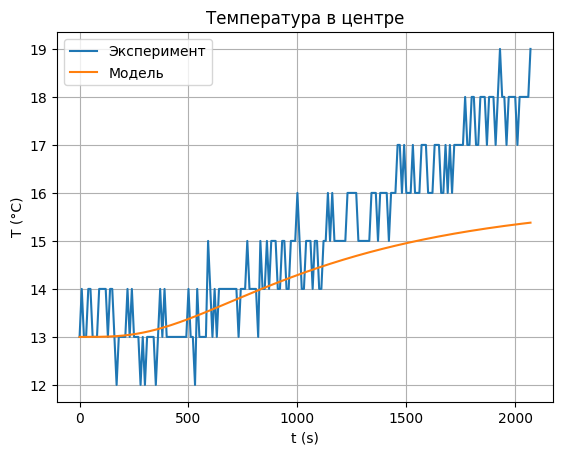

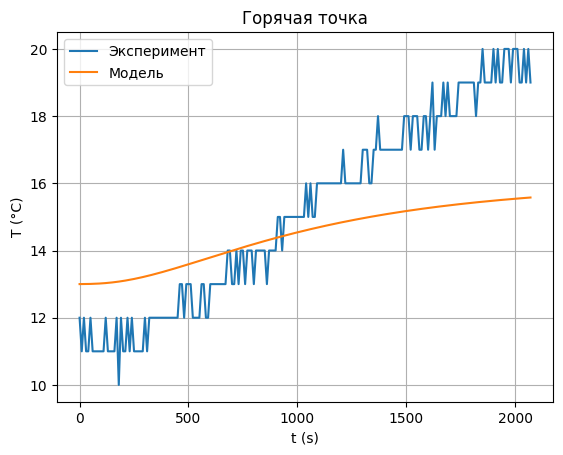

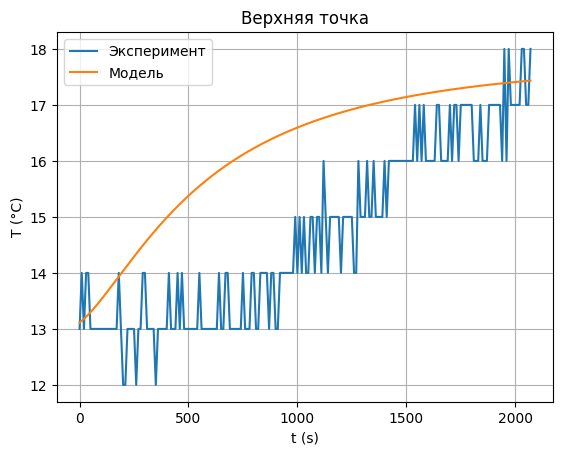

In [3]:
import matplotlib.pyplot as plt

Tc_model, Th_model, Tt_model, _= simulate(res.x[0], res.x[1], res.x[2])

plt.figure()
plt.plot(t_exp, T_center_exp, label="Эксперимент")
plt.plot(t_exp, Tc_model, label="Модель")
plt.title("Температура в центре")
plt.xlabel("t (s)")
plt.ylabel("T (°C)")
plt.legend()
plt.grid()

plt.figure()
plt.plot(t_exp, T_hot_exp, label="Эксперимент")
plt.plot(t_exp, Th_model, label="Модель")
plt.title("Горячая точка")
plt.xlabel("t (s)")
plt.ylabel("T (°C)")
plt.legend()
plt.grid()

plt.figure()
plt.plot(t_exp, T_top_exp, label="Эксперимент")
plt.plot(t_exp, Tt_model, label="Модель")
plt.title("Верхняя точка")
plt.xlabel("t (s)")
plt.ylabel("T (°C)")
plt.legend()
plt.grid()

plt.show()